# EDA: Student Final Test Score Prediction

Goal: predict `final_test`, a student's O-level mathematics exam score, from student, lifestyle, and school-related attributes.

This notebook follows the structure in `README.md`:
1. Initial inspection (`df.info()`, dtypes, duplicates)
2. Missing value handling
3. Data quality fixes
4. Feature engineering
5. Univariate analysis
6. Bivariate analysis
7. Correlation analysis
8. Feature decisions (keep/drop) and encoding
9. Train/validation/test split

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_style("whitegrid")


## 1. Initial inspection

In [2]:
df = pd.read_csv('./data/regression_bonus_practice_data.csv')
df.head()

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green
2,2,0,Yes,NaN,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               15900 non-null  int64  
 1   number_of_siblings  15900 non-null  int64  
 2   direct_admission    15900 non-null  str    
 3   CCA                 12071 non-null  str    
 4   learning_style      15900 non-null  str    
 5   student_id          15900 non-null  str    
 6   gender              15900 non-null  str    
 7   tuition             15900 non-null  str    
 8   final_test          15405 non-null  float64
 9   n_male              15900 non-null  float64
 10  n_female            15900 non-null  float64
 11  age                 15900 non-null  float64
 12  hours_per_week      15900 non-null  float64
 13  attendance_rate     15122 non-null  float64
 14  sleep_time          15900 non-null  str    
 15  wake_time           15900 non-null  str    
 16  mode_of_transpo

**Column reference (from README):**

| Column | Description | Type | Possible action |
|---|---|---|---|
| `index` | row index | Nominal | Remove |
| `student_id` | unique student ID | Nominal | Remove |
| `number_of_siblings` | # siblings | Ratio | Keep/Remove |
| `direct_admission` | admission mode (Yes/No) | Nominal | Keep, boolean encode/Remove |
| `CCA` | enrolled CCA | Nominal | Keep, categorical encode/Remove |
| `learning_style` | Visual/Auditory | Nominal | Keep, categorical encode/Remove |
| `tuition` | has tuition (Yes/No) | Nominal | Keep, boolean encode/Remove |
| `final_test` | O-level math score | Ratio | **Target** |
| `n_male` / `n_female` | # male/female classmates | Ratio | Keep/Remove |
| `gender` | Male/Female | Nominal | Keep, categorical encode/Remove |
| `age` | student age | Ratio | Keep/Remove |
| `hours_per_week` | study hours/week | Ratio | Keep/Remove |
| `attendance_rate` | attendance % | Ratio | Keep/Remove |
| `sleep_time` / `wake_time` | HH:MM strings | Interval | Feature-engineer into `sleep_hours_daily` |
| `mode_of_transport` | commute mode | Nominal | Keep, categorical encode/Remove |
| `bag_color` | bag colour | Nominal | Keep, categorical encode/Remove |

In [4]:
df.duplicated().sum()

np.int64(0)

No duplicate rows found — no deduplication needed.

In [5]:
df.isnull().sum()

index                    0
number_of_siblings       0
direct_admission         0
CCA                   3829
learning_style           0
student_id               0
gender                   0
tuition                  0
final_test             495
n_male                   0
n_female                 0
age                      0
hours_per_week           0
attendance_rate        778
sleep_time               0
wake_time                0
mode_of_transport        0
bag_color                0
dtype: int64

**Missing values found in 3 columns:** `CCA` (3,829), `final_test` (495), `attendance_rate` (778). Each is handled differently below, based on what a missing value most plausibly means for that column.

## 2. Missing value handling

**`final_test` (target, 495 missing) → drop rows.**

Without a `final_test` score, a row has no label to train or evaluate against. A missing score most plausibly means the student didn't sit the test at all — imputing a synthetic value (mean/median) for the *target* would inject fabricated signal into the one column the model is supposed to learn, so these rows are removed instead.

In [6]:
df = df.dropna(subset=['final_test'])
print(df['final_test'].isnull().sum())
print("Remaining rows:", len(df))

0
Remaining rows: 15405


**`CCA` (3,829 missing) → fill with `'None'`.**

A blank CCA plausibly means the student isn't enrolled in any CCA, rather than data lost at random — so it's treated as its own category instead of an unknown to impute.

In [7]:
df['CCA'] = df['CCA'].fillna('None')
print(df['CCA'].isnull().sum())
df['CCA'].value_counts(dropna=False)

0


CCA
Clubs     3803
Sports    3740
None      3707
Arts      3668
CLUBS      137
NONE       124
ARTS       123
SPORTS     103
Name: count, dtype: int64

**`attendance_rate` (778 missing) → fill with the column mean.**

Unlike `CCA`, a missing attendance rate has no natural interpretation in this dataset — there's no reason to think it means 0% or 100% attendance. With no explanatory pattern behind the gaps, filling with the mean is a reasonable default that avoids discarding otherwise-complete rows.

In [8]:
df['attendance_rate'] = df['attendance_rate'].fillna(df['attendance_rate'].mean())
print(df['attendance_rate'].isnull().sum())
df['attendance_rate'].describe()

0


count    15405.000000
mean        93.265770
std          7.787777
min         40.000000
25%         92.000000
50%         94.000000
75%         97.000000
max        100.000000
Name: attendance_rate, dtype: float64

## 3. Data quality fixes

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,15405.0,7942.309185,4589.766267,0.0,3977.0,7934.0,11909.0,15899.0
number_of_siblings,15405.0,0.886985,0.752139,0.0,0.0,1.0,1.0,2.0
final_test,15405.0,67.165401,13.977879,32.0,56.0,68.0,78.0,100.0
n_male,15405.0,13.878935,6.547230,0.0,10.0,14.0,18.0,31.0
n_female,15405.0,8.903083,6.661095,0.0,4.0,8.0,13.0,31.0
age,15405.0,15.214346,1.757209,-5.0,15.0,15.0,16.0,16.0
hours_per_week,15405.0,10.312301,4.463029,0.0,7.0,9.0,14.0,20.0
attendance_rate,15405.0,93.265770,7.787777,40.0,92.0,94.0,97.0,100.0


**`age` has invalid values (as low as -5).**

`age` should realistically be 14-16 for O-level students, but negative and single-digit values (4, 5, 6, -4, -5, -6) appear — almost certainly a data-entry error where a leading digit was dropped or the sign flipped. Since the erroneous values cluster tightly around the valid range (4↔14, 5↔15, 6↔16), it's reasonable to correct rather than drop these rows.

In [10]:
df[df['age'] < 5]

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
4513,4513,2,No,Sports,Auditory,RXTBXJ,Male,No,48.0,15.0,4.0,-4.0,2.0,94.0,21:30,5:30,public transport,red
7932,7932,1,No,Sports,Auditory,UAMI3G,Female,No,52.0,3.0,26.0,-5.0,13.0,92.0,21:00,5:00,public transport,yellow
8602,8602,0,No,None,Visual,XQMSBU,Female,No,67.0,10.0,18.0,-5.0,18.0,91.0,22:00,6:00,private transport,green
8663,8663,0,Yes,Arts,Visual,39XWY2,Male,Yes,85.0,17.0,3.0,-5.0,5.0,94.0,23:00,7:00,walk,blue
8846,8846,2,No,Sports,Auditory,Z33FOS,Female,Yes,74.0,4.0,19.0,-5.0,13.0,90.0,22:00,6:00,private transport,white


In [11]:
df['age'] = df['age'].abs()
df['age'] = df['age'].replace(4, 14)
df['age'] = df['age'].replace(5, 15)
df['age'] = df['age'].replace(6, 16)

**`CCA` and `tuition` have inconsistent casing/labels.**

`CCA` mixes Pascal Case and ALL CAPS for the same categories (`Sports`/`SPORTS`, etc.), and `tuition` mixes `Yes`/`No` with `Y`/`N`. These are standardized to a single consistent label per category so they aren't treated as distinct groups downstream.

In [12]:
df['CCA'] = df['CCA'].replace('ARTS', 'Arts')
df['CCA'] = df['CCA'].replace('SPORTS', 'Sports')
df['CCA'] = df['CCA'].replace('NONE', 'None')
df['CCA'] = df['CCA'].replace('CLUBS', 'Clubs')
df['CCA'].value_counts()

CCA
Clubs     3940
Sports    3843
None      3831
Arts      3791
Name: count, dtype: int64

In [13]:
df['tuition'] = df['tuition'].replace('Y', 'Yes')
df['tuition'] = df['tuition'].replace('N', 'No')
df['tuition'].value_counts()

tuition
Yes    8716
No     6689
Name: count, dtype: int64

## 4. Feature engineering

**`sleep_time` + `wake_time` → `sleep_hours_daily`.**

The two raw HH:MM columns aren't directly usable as numeric features. Converting them to minutes since midnight and taking the (wraparound-aware) difference produces a single continuous sleep-duration feature.

In [14]:
sleep_min = pd.to_datetime(df['sleep_time'], format='%H:%M').dt.hour * 60 \
          + pd.to_datetime(df['sleep_time'], format='%H:%M').dt.minute
wake_min  = pd.to_datetime(df['wake_time'],  format='%H:%M').dt.hour * 60 \
          + pd.to_datetime(df['wake_time'],  format='%H:%M').dt.minute

# Sleep duration in hours; modulo handles the overnight wraparound
df['sleep_hours_daily'] = ((wake_min - sleep_min) % (24 * 60)) / 60

df[['sleep_time', 'wake_time', 'sleep_hours_daily']].head()

,sleep_time,wake_time,sleep_hours_daily
0,22:00,6:00,8.0
1,22:30,6:30,8.0
2,22:30,6:30,8.0
3,21:00,5:00,8.0
4,21:30,5:30,8.0


## 5. Univariate analysis

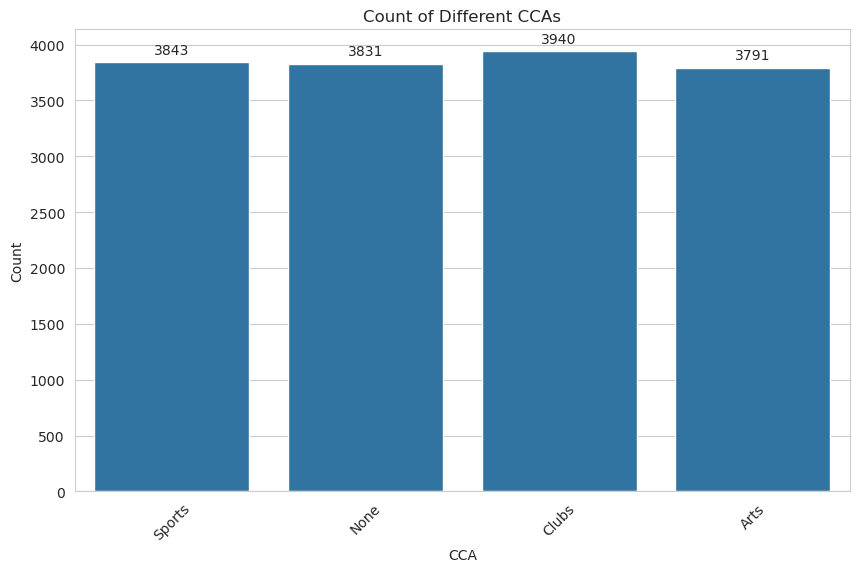

In [15]:
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='CCA', data=df)
plt.title('Count of Different CCAs')
plt.xlabel('CCA')
plt.ylabel('Count')
plt.xticks(rotation=45)
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()

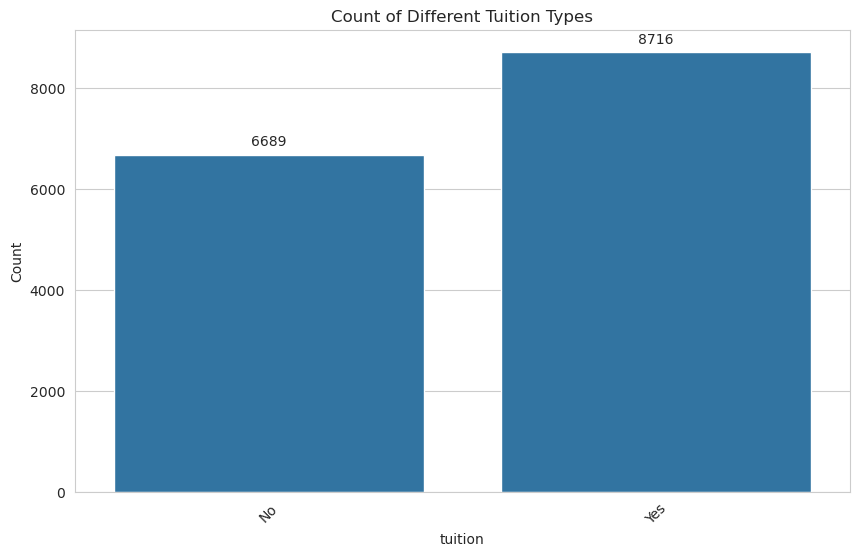

In [16]:
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='tuition', data=df)
plt.title('Count of Different Tuition Types')
plt.xlabel('tuition')
plt.ylabel('Count')
plt.xticks(rotation=45)
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()

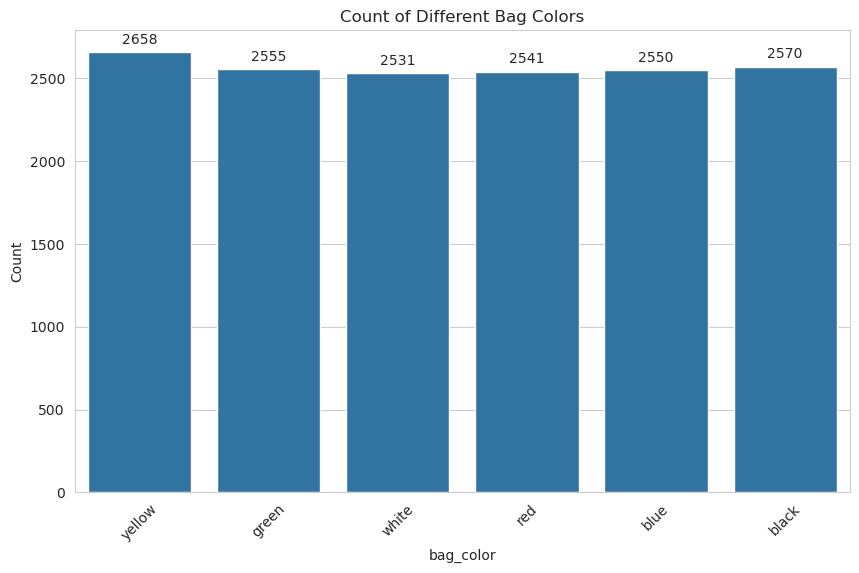

In [17]:
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='bag_color', data=df)
plt.title('Count of Different Bag Colors')
plt.xlabel('bag_color')
plt.ylabel('Count')
plt.xticks(rotation=45)
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()

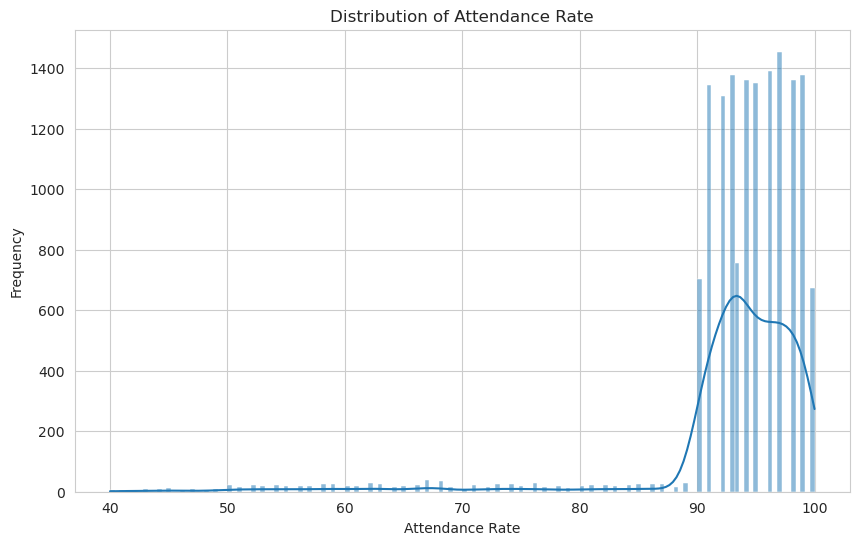

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['attendance_rate'], kde=True)
plt.title('Distribution of Attendance Rate')
plt.xlabel('Attendance Rate')
plt.ylabel('Frequency')
plt.show()

## 6. Binary encoding of Yes/No and gender features

`direct_admission`, `tuition`, and `gender` are binary categoricals. Encoding them to 0/1 now makes them usable both in boxplots below and in the numeric correlation matrix later. `gender` is renamed to `is_male` to make the encoding direction unambiguous.

In [19]:
binary_map = {'Yes': 1, 'No': 0}
df = df.rename(columns={'gender': 'is_male'})

df['direct_admission'] = df['direct_admission'].replace(binary_map)
df['tuition']          = df['tuition'].replace(binary_map)
df['is_male']          = df['is_male'].replace({'Male': 1, 'Female': 0})

df[['direct_admission', 'tuition', 'is_male']].head()

,direct_admission,tuition,is_male
0,1,0,0
1,0,0,0
2,1,0,1
3,0,1,0
4,0,0,1


## 7. Bivariate analysis: all features vs `final_test`

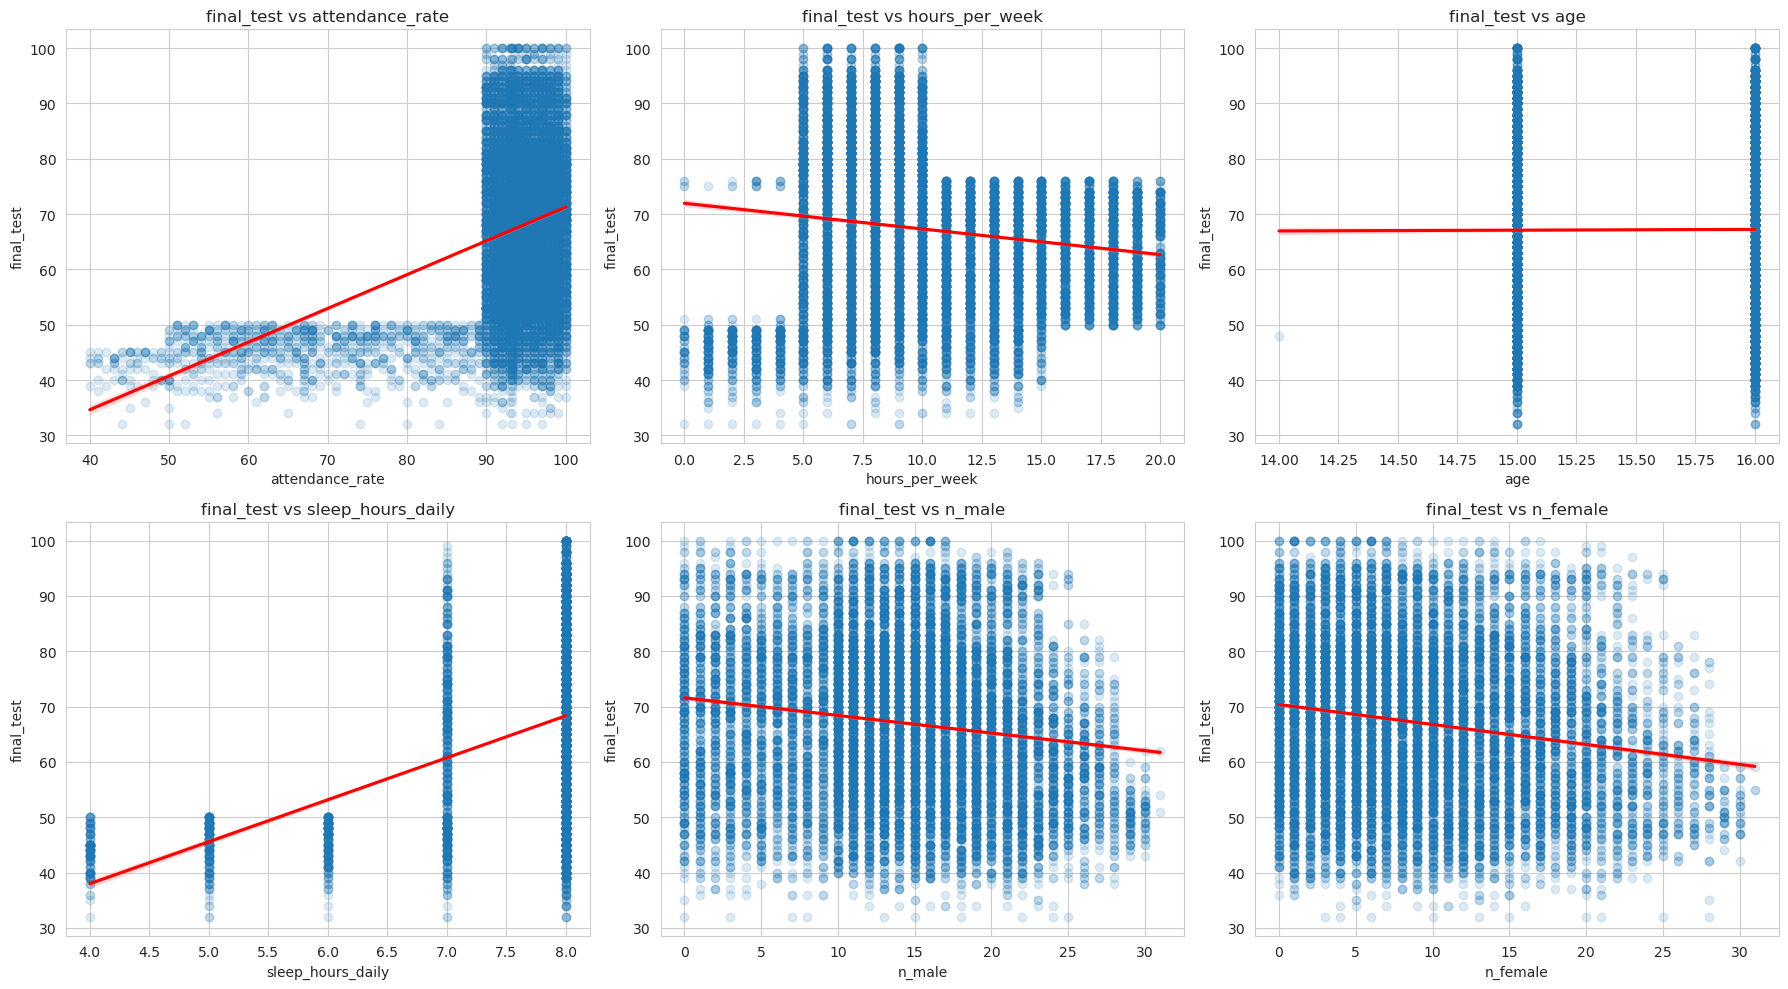

In [20]:
num_features = ['attendance_rate', 'hours_per_week', 'age', 'sleep_hours_daily', 'n_male', 'n_female']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, num_features):
    sns.regplot(x=col, y='final_test', data=df, ax=ax,
                scatter_kws={'alpha': 0.15}, line_kws={'color': 'red'})
    ax.set_title(f'final_test vs {col}')
plt.tight_layout()
plt.show()

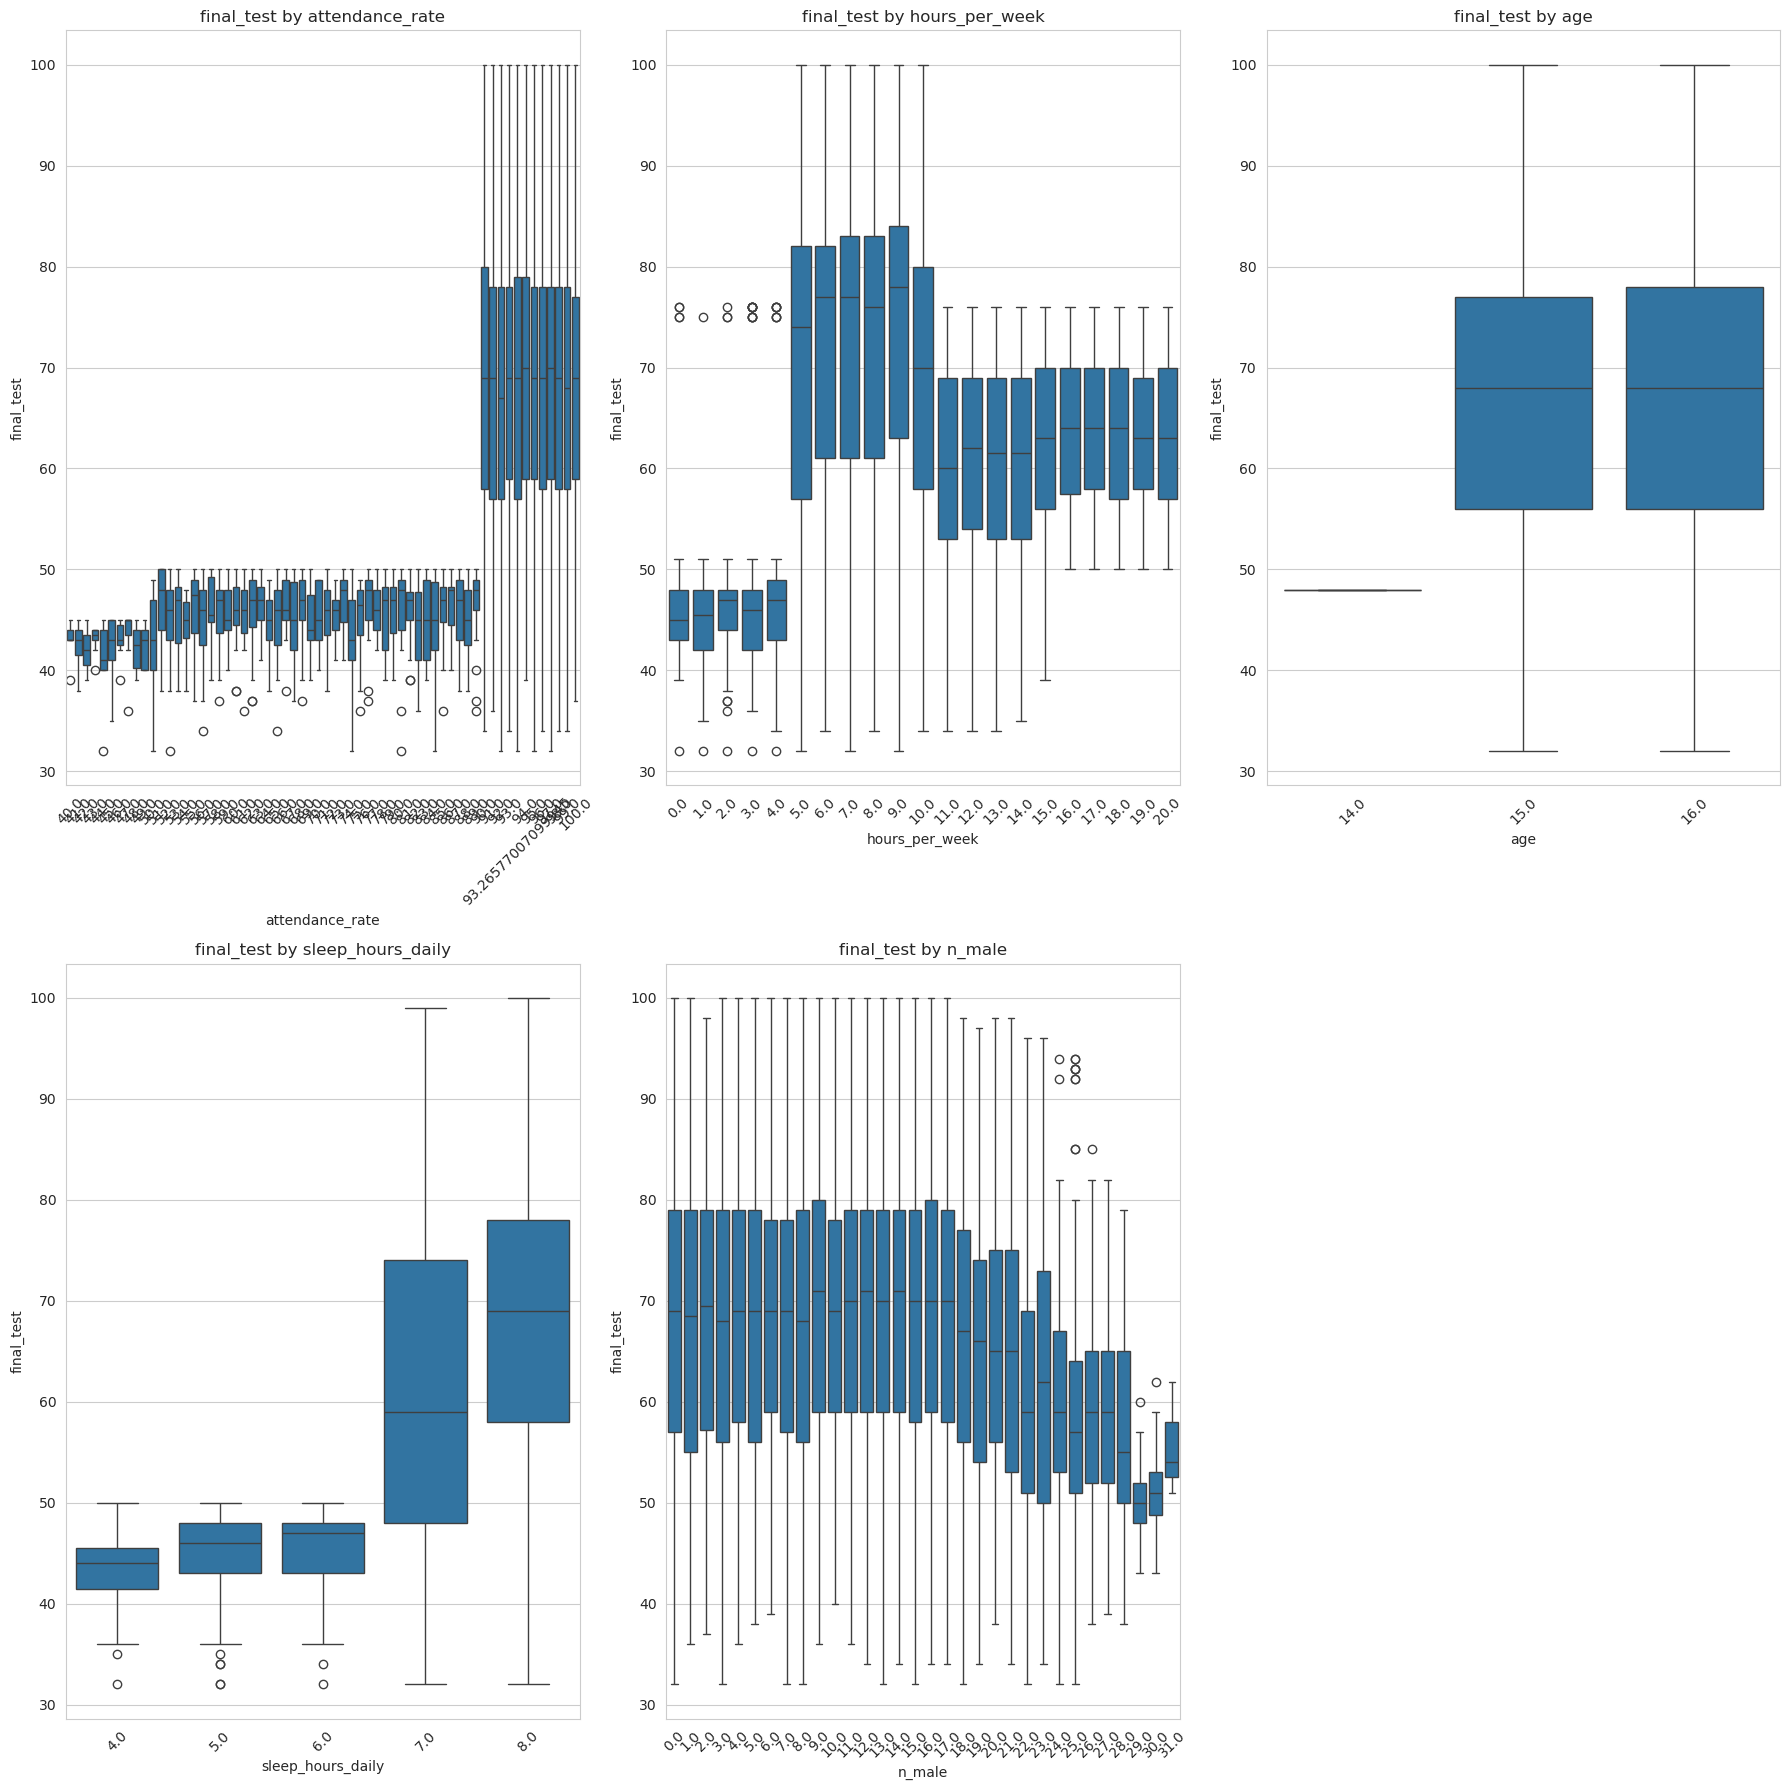

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 18))
for ax, col in zip(axes.flat, num_features):
    sns.boxplot(x=col, y='final_test', data=df, ax=ax)
    ax.set_title(f'final_test by {col}')
    ax.tick_params(axis='x', rotation=45)
fig.delaxes(axes.flat[5])  # only 6 features, remove the empty 6th panel
plt.tight_layout()
plt.show()

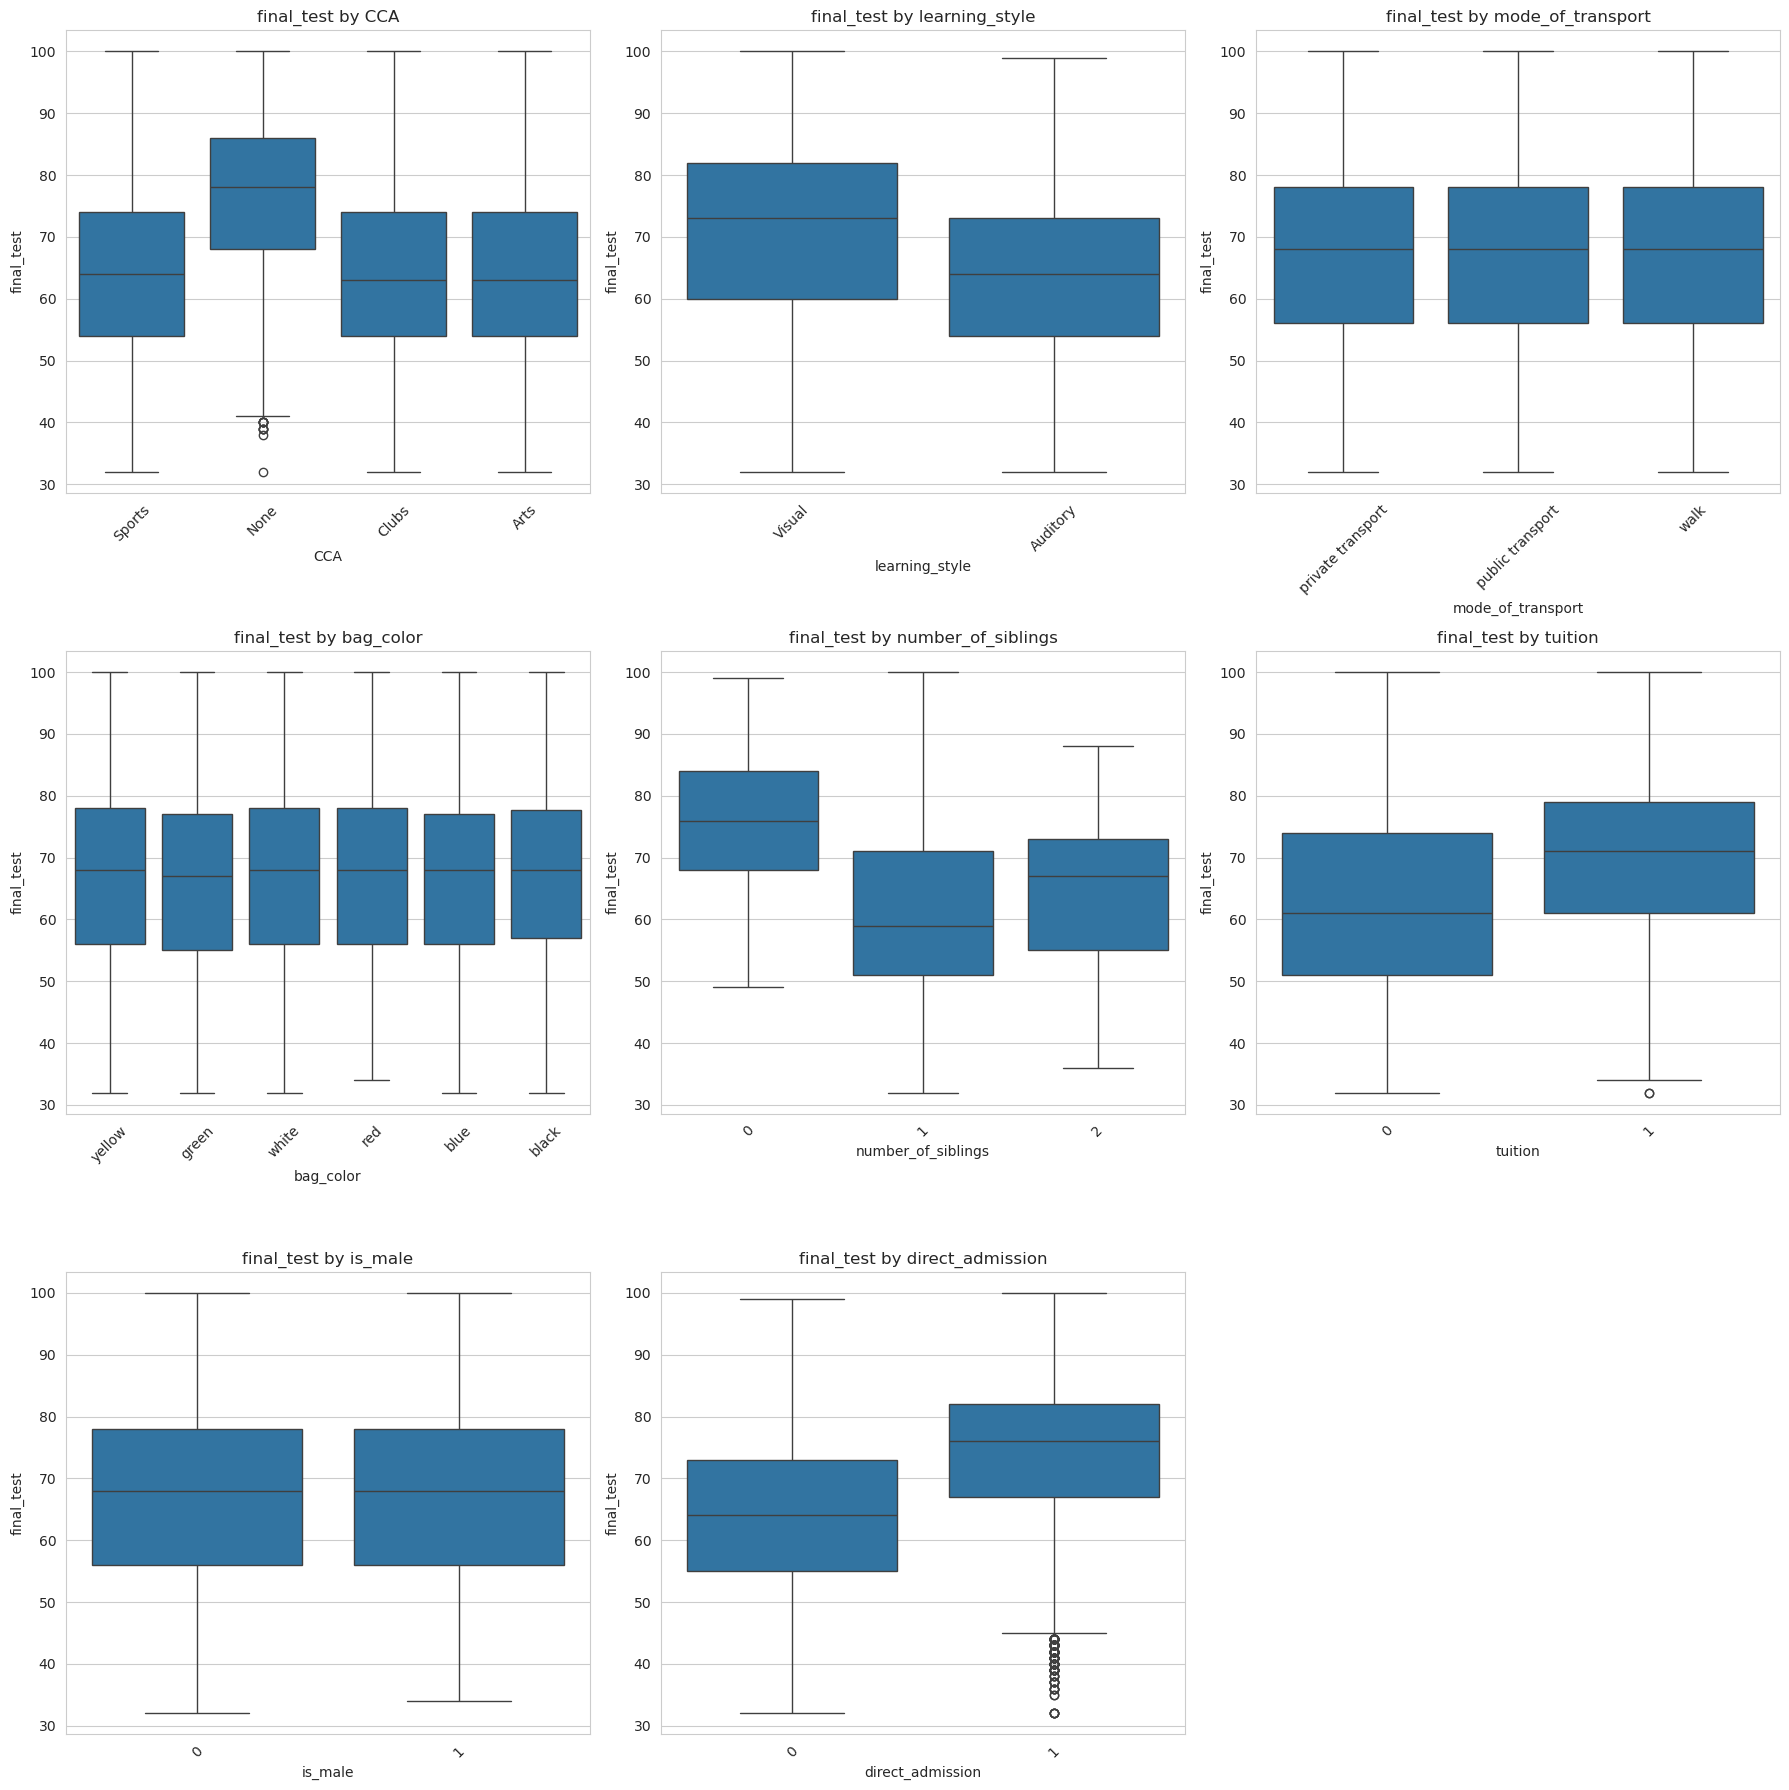

In [22]:
cat_features = ['CCA', 'learning_style', 'mode_of_transport', 'bag_color', 'number_of_siblings', 'tuition', 'is_male', 'direct_admission']

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
for ax, col in zip(axes.flat, cat_features):
    sns.boxplot(x=col, y='final_test', data=df, ax=ax)
    ax.set_title(f'final_test by {col}')
    ax.tick_params(axis='x', rotation=45)
fig.delaxes(axes.flat[8])  # only 8 features, remove the empty 9th panel
plt.tight_layout()
plt.show()

**Quantitative group-mean checks**, to back the visual impressions above with numbers.

In [23]:
for col in ['is_male', 'tuition', 'direct_admission']:
    print(f"\n{col}:")
    print(df.groupby(col)['final_test'].agg(['mean', 'count']))


is_male:
              mean  count
is_male                  
0        66.999869   7661
1        67.329158   7744

tuition:
              mean  count
tuition                  
0        62.864404   6689
1        70.466154   8716

direct_admission:
                       mean  count
direct_admission                  
0                 64.989500  10857
1                 72.359719   4548


- `is_male`: 66.99 vs 67.33 — negligible difference. **Candidate for removal.**
- `tuition`: 62.86 vs 70.47 — clear, meaningful gap. **Keep.**
- `direct_admission`: 64.99 vs 72.36 — clear, meaningful gap. **Keep.**

In [24]:
for col in ['learning_style', 'CCA']:
    print(f"\n{col}:")
    print(df.groupby(col)['final_test'].agg(['mean', 'median', 'std', 'count']))


learning_style:
                     mean  median        std  count
learning_style                                     
Auditory        63.888324    64.0  13.114772   8847
Visual          71.586307    73.0  13.889588   6558

CCA:
             mean  median        std  count
CCA                                        
Arts    64.061989    63.0  13.158185   3791
Clubs   63.850761    63.0  12.972272   3940
None    76.778648    78.0  12.153547   3831
Sports  64.041894    64.0  13.042459   3843


- **`learning_style`**: Visual averages 71.6 vs Auditory 63.9 — a ~7.7-point gap. Strong, real effect. **Keep**, one-hot encode.
- **`CCA`**: `None` stands out at 76.8 mean; Arts/Clubs/Sports are all clustered tightly around 64. **Keep**, and encode as a full four-way one-hot (Arts/Clubs/Sports/None).

**Visual-only checks: `mode_of_transport`, `bag_color`, `age`, `n_male`/`n_female`.**

The boxplots above show no meaningful separation in `final_test` across `mode_of_transport` or `bag_color` categories, and no visible relationship for `age`. `n_male`/`n_female` are quantified in the correlation analysis below.

## 8. Correlation analysis

Pearson measures **linear** correlation; Spearman measures **monotonic** (rank-based) correlation. Computing both against `final_test` gives a cross-check: features that rank similarly under both methods are more robustly related to the target.

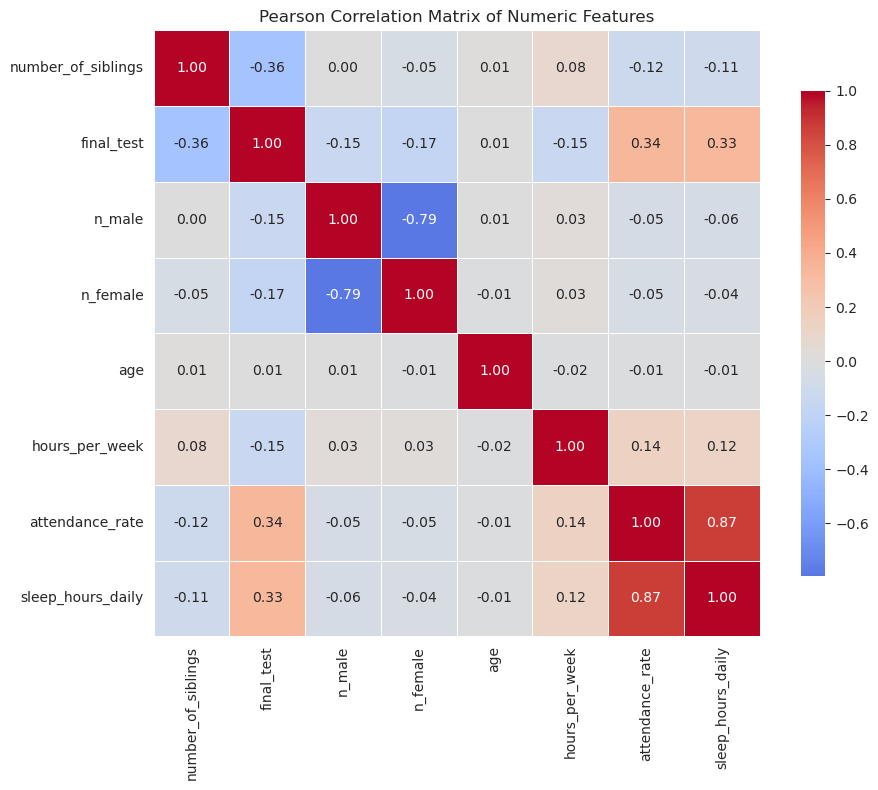

In [25]:
numeric_cols = df.select_dtypes(include='number').columns.drop('index', errors='ignore')

corr_pearson = df[numeric_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Pearson Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

In [26]:
target_corr_pearson = corr_pearson['final_test'].drop('final_test').sort_values(key=abs, ascending=False)
print(target_corr_pearson)

number_of_siblings   -0.363767
attendance_rate       0.340307
sleep_hours_daily     0.327213
n_female             -0.171978
n_male               -0.149152
hours_per_week       -0.148254
age                   0.005179
Name: final_test, dtype: float64


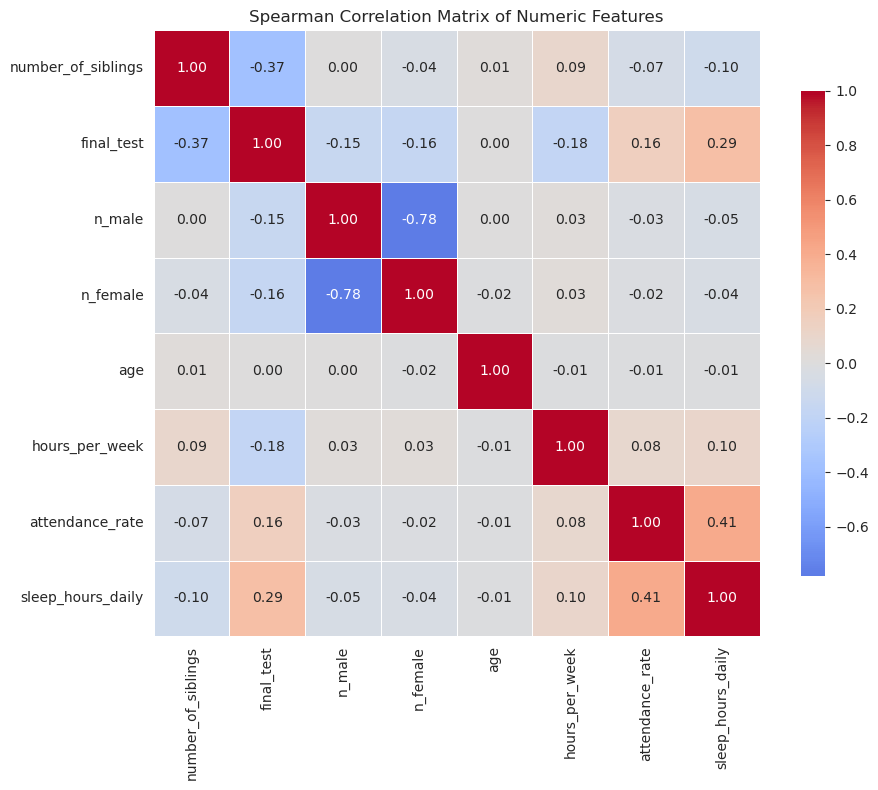

In [27]:
corr_spearman = df[numeric_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Spearman Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

In [28]:
target_corr_spearman = corr_spearman['final_test'].drop('final_test').sort_values(key=abs, ascending=False)
print(target_corr_spearman)

number_of_siblings   -0.369936
sleep_hours_daily     0.287414
hours_per_week       -0.180432
attendance_rate       0.162740
n_female             -0.161848
n_male               -0.152408
age                   0.004166
Name: final_test, dtype: float64


**Reading the two rankings together:**

`number_of_siblings`, `attendance_rate`, `sleep_hours_daily` are the strongest predictors under both methods. `age` is weak under both — consistent with the group-mean findings above, and confirming it add little value. `n_male`/`n_female` are moderately correlated with the target but, as shown by the near-perfect inverse relationship between them (same classroom headcount), are redundant with each other.

### Collinearity check: `attendance_rate` vs `sleep_hours_daily`

Both features show a similar-strength relationship with `final_test` (Pearson ≈ 0.34 vs 0.33). Before keeping both, check whether they're actually redundant with each other.

In [29]:
pearson_r = df['attendance_rate'].corr(df['sleep_hours_daily'], method='pearson')
spearman_r = df['attendance_rate'].corr(df['sleep_hours_daily'], method='spearman')

print(f"Pearson correlation:  {pearson_r:.4f}")
print(f"Spearman correlation: {spearman_r:.4f}")

Pearson correlation:  0.8689
Spearman correlation: 0.4109


Pearson (~0.87) and Spearman (~0.41) disagree sharply. To understand why, look at the actual distribution of `sleep_hours_daily` rather than trusting either coefficient blindly.

In [30]:
print(df['sleep_hours_daily'].value_counts(normalize=True).sort_index())
print()
print(df.groupby('sleep_hours_daily')['attendance_rate'].mean())

sleep_hours_daily
4.0    0.009542
5.0    0.014735
6.0    0.015125
7.0    0.041091
8.0    0.919507
Name: proportion, dtype: float64

sleep_hours_daily
4.0    51.015843
5.0    59.985276
6.0    68.544736
7.0    87.267360
8.0    94.912251
Name: attendance_rate, dtype: float64


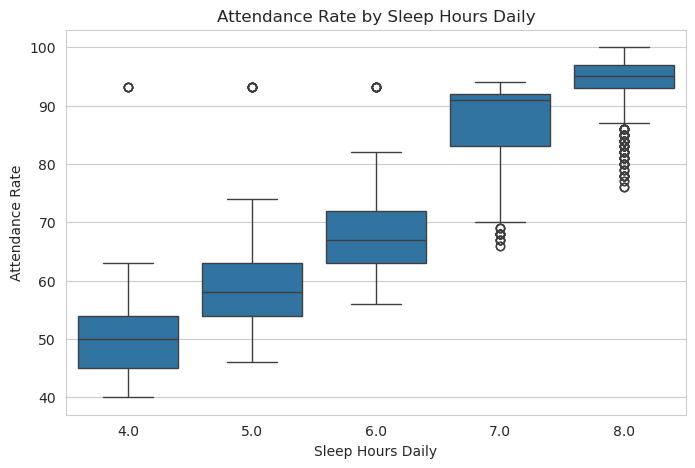

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='sleep_hours_daily', y='attendance_rate', data=df)
plt.title('Attendance Rate by Sleep Hours Daily')
plt.xlabel('Sleep Hours Daily')
plt.ylabel('Attendance Rate')
plt.show()

**Why the two coefficients disagree:**

`sleep_hours_daily` is heavily concentrated at a single value — about 92% of students sleep exactly 8 hours, with the remaining ~8% spread thinly across 4, 5, 6, and 7 hours. It behaves more like a lumpy, mostly-constant feature than a continuous one.

- **Pearson** uses raw values and picks up a strong, steady increase in mean `attendance_rate` as sleep hours rise (51 → 60 → 69 → 87 → 95). Because that trend is close to linear and the dominant cluster (8 hrs, ~95% attendance) anchors it tightly, Pearson reports a high correlation (~0.87).
- **Spearman** first converts values to ranks. With ~92% of rows tied at 8 hours, they all collapse to the same average rank — so Spearman loses most of its ability to differentiate. That tie-heavy ranking waters the coefficient down to ~0.41.

The two metrics aren't contradicting each other — they're sensitive to different things, and Pearson is the more informative measure here since it preserves the magnitude information that Spearman's ranking discards. The underlying relationship is real.

**Decision: drop `sleep_hours_daily`, keep `attendance_rate`.**

- The two features are strongly collinear (Pearson 0.87), nearly as strong as either is with the target — keeping both adds redundancy without much extra signal.
- `attendance_rate` is the more reliable of the two: it's a genuinely continuous measure across ~60 distinct values, whereas `sleep_hours_daily` is derived, mostly constant (92% at one value from just 5 distinct values), and far less granular.
- Excluding the 5% of imputed `attendance_rate` rows doesn't weaken this conclusion — if anything the real (non-imputed) data shows an even stronger case for keeping `attendance_rate` over `sleep_hours_daily`.
- Removing `sleep_hours_daily` reduces multicollinearity risk for linear models and simplifies the feature set without losing predictive information.

In [32]:
df = df.drop(columns=['sleep_hours_daily', 'sleep_time', 'wake_time'])
df.columns

Index(['index', 'number_of_siblings', 'direct_admission', 'CCA',
       'learning_style', 'student_id', 'is_male', 'tuition', 'final_test',
       'n_male', 'n_female', 'age', 'hours_per_week', 'attendance_rate',
       'mode_of_transport', 'bag_color'],
      dtype='str')

## 9. Feature decisions summary

**Dropped:**

| Feature | Reason |
|---|---|
| `index`, `student_id` | row identifiers, no predictive value |
| `bag_color` | no relationship with target (boxplot) |
| `mode_of_transport` | no relationship with target (boxplot) |
| `age` | corrected data still shows ~0 correlation with target |
| `is_male` (`gender`) | negligible group-mean difference (67.0 vs 67.3) |
| `n_male`, `n_female` | correlated with each other; weaker relationship with target than kept features |
| `sleep_time`, `wake_time`, `sleep_hours_daily` | collinear with `attendance_rate` (Pearson 0.87); `attendance_rate` is the stronger, more granular signal |

**Kept, as-is (numeric):** `number_of_siblings`, `attendance_rate`, `hours_per_week`

**Kept, binary-encoded:** `direct_admission`, `tuition` (already 0/1 from Section 6)

**Kept, one-hot encoded:**
- `learning_style` (Visual/Auditory) — strong, significant group-mean gap
- `CCA` (Arts/Clubs/Sports/None) — kept as full **four-way** encoding, to preserve any activity-specific effects even though the ANOVA signal is driven mostly by None vs. any-CCA

**Target:** `final_test`

## 10. Data splitting

In [33]:
drop_cols = ['final_test', 'index', 'student_id', 'is_male', 'mode_of_transport', 'bag_color', 'age', 'n_male', 'n_female']
X = df.drop(columns=drop_cols)
y = df['final_test']
X.head()

,number_of_siblings,direct_admission,CCA,learning_style,tuition,hours_per_week,attendance_rate
0,0,1,Sports,Visual,0,10.0,91.00000
1,2,0,Sports,Auditory,0,7.0,94.00000
2,0,1,None,Visual,0,8.0,92.00000
3,1,0,Clubs,Auditory,1,18.0,93.26577
4,0,0,Sports,Auditory,0,7.0,95.00000


In [34]:
from sklearn.model_selection import train_test_split

# 80% train, 20% held out
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the held-out 20% evenly into validation (10%) and test (10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [35]:
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (12324, 7) (12324,)
Validation set shape: (1540, 7) (1540,)
Test set shape: (1541, 7) (1541,)
